In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
import os
print(os.getcwd())

C:\Users\KIIT0001


In [19]:
trader = pd.read_csv("C:/Users/KIIT0001/Downloads/historical_data.csv")
sentiment = pd.read_csv("C:/Users/KIIT0001/Downloads/fear_greed_index.csv")


In [21]:
import os
print(os.listdir())

['.anaconda', '.cache', '.codeium', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.dbus-keyrings', '.gitconfig', '.gnuradio', '.idea', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.m2', '.matplotlib', '.ms-ad', '.nbi', '.node_repl_history', '.nuget', '.ollama', '.opera', '.packettracer', '.python_history', '.redhat', '.templateengine', '.th-client', '.thumbnails', '.viminfo', '.VirtualBox', '.vscode', '.Xilinx', '2329049', '2329049_DAA SESSIONAL QUESTION 1', 'anaconda3', 'AP1.py', 'AP1q1.py', 'AP1q2.py', 'AP1q3.py', 'AP1q4.py', 'AP1q5.py', 'AP2.py', 'AP2q1.py', 'AP3.py', 'AP3q1.py', 'AP3q10.py', 'AP3q11.py', 'AP3q12.py', 'AP3q2.py', 'AP3q3.py', 'AP3q4.py', 'AP3q5.py', 'AP3q6.py', 'AP3q7.py', 'AP3q8.py', 'AP3q9.py', 'AP4q1.py', 'AP4q10.py', 'AP4q11.py', 'AP4q12.py', 'AP4q2.py', 'AP4q3.py', 'AP4q4.py', 'AP4q4.txt', 'AP4q5.py', 'AP4q6.py', 'AP4q7.py', 'AP4q8.py', 'AP4q9.py', 'AppData', 'Application Data', 'Assignment', 'chat_log.csv', 'Cisc

In [36]:
trader = pd.read_csv("historical_data .csv")
sentiment = pd.read_csv("fear_greed_index .csv")

In [34]:
trader = pd.read_csv("historical_data .csv")
sentiment = pd.read_csv("fear_greed_index .csv")

In [32]:
import os
print(os.listdir())

['.anaconda', '.cache', '.codeium', '.conda', '.condarc', '.config', '.continuum', '.copilot', '.dbus-keyrings', '.gitconfig', '.gnuradio', '.idea', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.lesshst', '.m2', '.matplotlib', '.ms-ad', '.nbi', '.node_repl_history', '.nuget', '.ollama', '.opera', '.packettracer', '.python_history', '.redhat', '.templateengine', '.th-client', '.thumbnails', '.viminfo', '.VirtualBox', '.vscode', '.Xilinx', '2329049', '2329049_DAA SESSIONAL QUESTION 1', 'anaconda3', 'AP1.py', 'AP1q1.py', 'AP1q2.py', 'AP1q3.py', 'AP1q4.py', 'AP1q5.py', 'AP2.py', 'AP2q1.py', 'AP3.py', 'AP3q1.py', 'AP3q10.py', 'AP3q11.py', 'AP3q12.py', 'AP3q2.py', 'AP3q3.py', 'AP3q4.py', 'AP3q5.py', 'AP3q6.py', 'AP3q7.py', 'AP3q8.py', 'AP3q9.py', 'AP4q1.py', 'AP4q10.py', 'AP4q11.py', 'AP4q12.py', 'AP4q2.py', 'AP4q3.py', 'AP4q4.py', 'AP4q4.txt', 'AP4q5.py', 'AP4q6.py', 'AP4q7.py', 'AP4q8.py', 'AP4q9.py', 'AppData', 'Application Data', 'Assignment', 'chat_log.csv', 'Cisc

In [38]:
print(trader.columns)
print(sentiment.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')
Index(['timestamp', 'value', 'classification', 'date'], dtype='object')


In [42]:
trader['Timestamp'] = pd.to_datetime(trader['Timestamp']).dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [44]:
merged = pd.merge(trader, sentiment, left_on="Timestamp", right_on="date")

print(merged.head())

Empty DataFrame
Columns: [Account, Coin, Execution Price, Size Tokens, Size USD, Side, Timestamp IST, Start Position, Direction, Closed PnL, Transaction Hash, Order ID, Crossed, Fee, Trade ID, Timestamp, timestamp, value, classification, date]
Index: []


In [46]:
profit_by_sentiment = merged.groupby("classification")["Closed PnL"].mean()

print(profit_by_sentiment)

Series([], Name: Closed PnL, dtype: float64)


In [52]:
print(merged.shape)

(0, 20)


In [64]:
print(trader['trade_date'].min(), trader['trade_date'].max())
print(sentiment['sentiment_date'].min(), sentiment['sentiment_date'].max())

2023-05-01 2025-05-01
2018-02-01 2025-05-02


In [66]:
sentiment.tail()

,timestamp,value,classification,date,sentiment_date
2639,1745818200,54,Neutral,2025-04-28,2025-04-28
2640,1745904600,60,Greed,2025-04-29,2025-04-29
2641,1745991000,56,Greed,2025-04-30,2025-04-30
2642,1746077400,53,Neutral,2025-05-01,2025-05-01
2643,1746163800,67,Greed,2025-05-02,2025-05-02


In [68]:
trader['trade_date'] = pd.to_datetime(trader['Timestamp IST'], dayfirst=True)
sentiment['sentiment_date'] = pd.to_datetime(sentiment['date'])

In [70]:
trader['trade_date'] = trader['trade_date'].dt.date
sentiment['sentiment_date'] = sentiment['sentiment_date'].dt.date

In [72]:
merged = pd.merge(
    trader,
    sentiment,
    left_on='trade_date',
    right_on='sentiment_date',
    how='inner'
)

print(merged.shape)

(211218, 22)


In [74]:
profit_by_sentiment = merged.groupby("classification")["Closed PnL"].mean()
print(profit_by_sentiment)

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


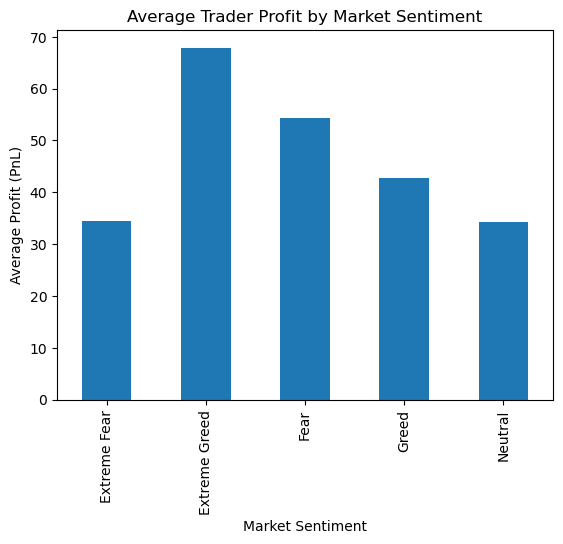

In [76]:
import matplotlib.pyplot as plt

profit_by_sentiment.plot(kind="bar")

plt.title("Average Trader Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Profit (PnL)")
plt.show()

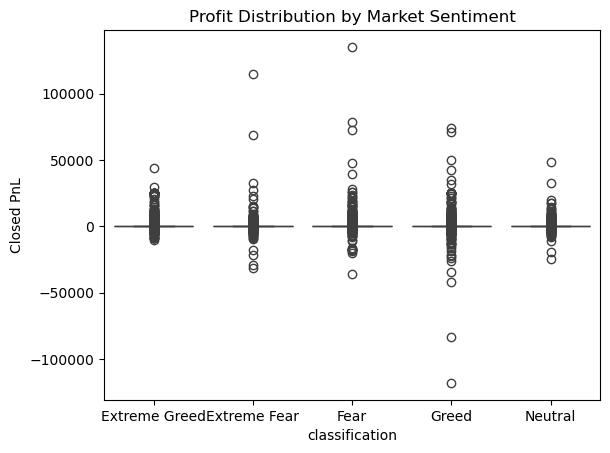

In [78]:
import seaborn as sns

sns.boxplot(x="classification", y="Closed PnL", data=merged)

plt.title("Profit Distribution by Market Sentiment")
plt.show()

In [80]:
direction_analysis = merged.groupby(["classification","Side"])["Closed PnL"].mean()
print(direction_analysis)

classification  Side
Extreme Fear    BUY      34.114627
                SELL     34.980106
Extreme Greed   BUY      10.498927
                SELL    114.584643
Fear            BUY      63.927104
                SELL     45.049641
Greed           BUY      25.002302
                SELL     59.691091
Neutral         BUY      29.227429
                SELL     39.456408
Name: Closed PnL, dtype: float64


In [82]:
size_analysis = merged.groupby("classification")["Size USD"].mean()
print(size_analysis)

classification
Extreme Fear     5349.731843
Extreme Greed    3112.251565
Fear             7816.109931
Greed            5736.884375
Neutral          4782.732661
Name: Size USD, dtype: float64


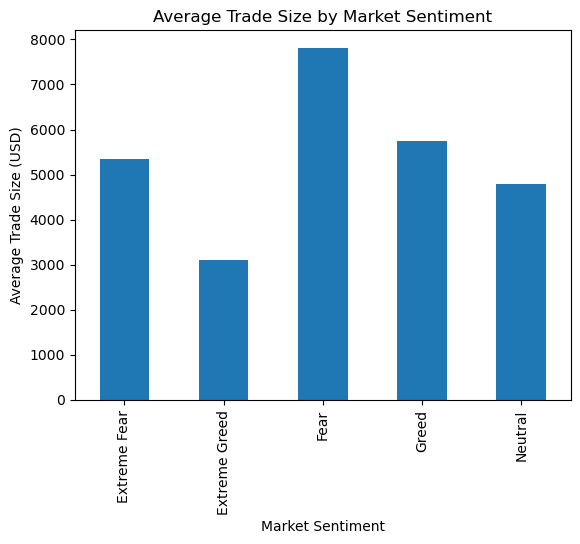

In [84]:
size_analysis.plot(kind="bar")

plt.title("Average Trade Size by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.show()

In [86]:
top_traders = merged.groupby("Account")["Closed PnL"].sum().sort_values(ascending=False).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64


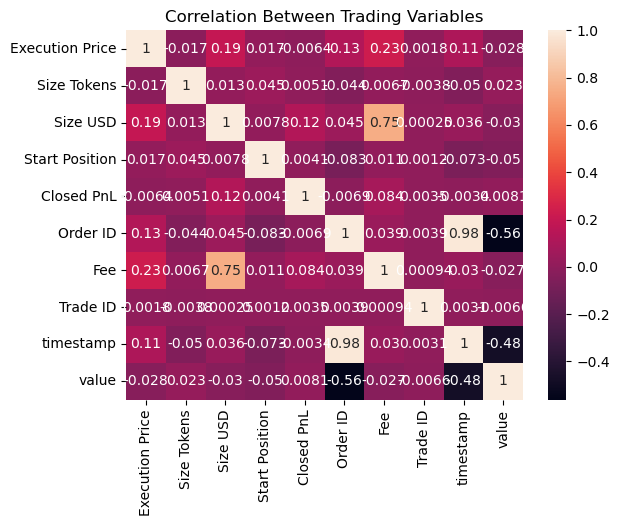

In [88]:
import seaborn as sns

numeric_cols = merged.select_dtypes(include=['float64','int64'])

sns.heatmap(numeric_cols.corr(), annot=True)

plt.title("Correlation Between Trading Variables")
plt.show()

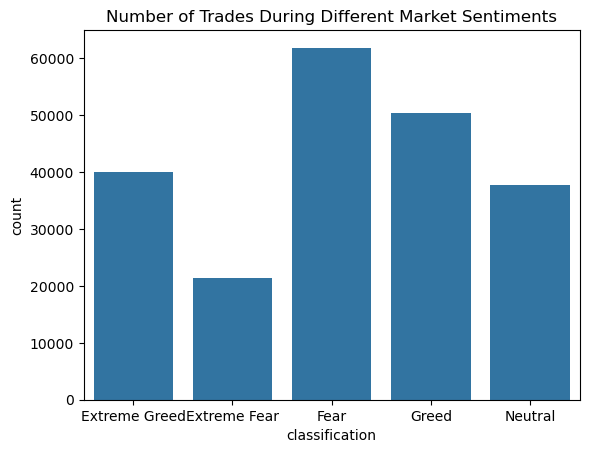

In [94]:
sns.countplot(x="classification", data=merged)

plt.title("Number of Trades During Different Market Sentiments")
plt.show()